<a href="https://colab.research.google.com/github/abdullah2709/EAAI_Project/blob/main/EAAI_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting (Accident & Emergency) waiting times in the NHS**

# 1. Introduction
The 4-hour A&E standard is a key operational performance indicator within the National Health Service. It measures the percentage of patients admitted, transferred, or discharged within four hours of arrival.

Declining performance has raised concerns about system pressure and capacity constraints. This project applies artificial intelligence techniques to predict monthly A&E 4-hour performance using historical data published by NHS England.

# Aim
To develop and evaluate AI models that predict monthly A&E 4-hour performance percentage.

# Objectives
 1. Clean and prepare NHS monthly A&E data

 2. Perform exploratory data analysis (EDA)

 3. Engineer time-based and seasonal features

 4. Apply:

    Linear Regression

    Random Forest

    ARIMA

 5. Compare performance using MAE, RMSE, and R²

 6. Critically evaluate results

# 2. Load Dataset
**Step 1 : Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA

**Step 2 : Load the CSV**

In [ ]:
url = "https://raw.githubusercontent.com/abdullah2709/EAAI_Project/refs/heads/main/AE_attendances_england_monthly%20(1).csv"

In [ ]:
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 27112 entries, 0 to 27111
Data columns (total 20 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   Unnamed: 0                                                                 27112 non-null  int64  
 1   date                                                                       27112 non-null  str    
 2   Name                                                                       27108 non-null  str    
 3   Type 1 Departments - Major A&E                                             27112 non-null  float64
 4   Type 2 Departments - Single Specialty                                      27112 non-null  float64
 5   Type 3 Departments - Other A&E/Minor Injury Unit                           27112 non-null  float64
 6   Total attendances                                                

Index(['Unnamed: 0', 'date', 'Name', 'Type 1 Departments - Major A&E',
       'Type 2 Departments - Single Specialty',
       'Type 3 Departments - Other A&E/Minor Injury Unit', 'Total attendances',
       'Type 1 Departments - 4 hours to decision',
       'Type 2 Departments - 4 hours to decision',
       'Type 3 Departments - 4 hours to decision',
       'Percentage in 4 hours or less (all)',
       'Emergency Admissions via Type 1 A&E in 4 hours',
       'Emergency Admissions via Type 2 A&E in 4 hours',
       'Emergency Admissions via Type 3 and 4 A&E in 4 hours',
       'Other Emergency admissions (i.e not via A&E)',
       'Number of patients spending >12 hours from decision to admit to admission',
       'month', 'year', 'lat', 'lon'],
      dtype='str')

# 3. Data Cleaning

**Convert Month Column**

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

**Rename the Column**

In [ ]:
df = df.rename(columns={
    'Percentage in 4 hours or less (all)': 'Four_Hour_Performance'
})

**Handle Missing Values**

In [ ]:
df = df.dropna()

# 4. Exploratory Data Analysis (EDA)

**Trend Over Time**

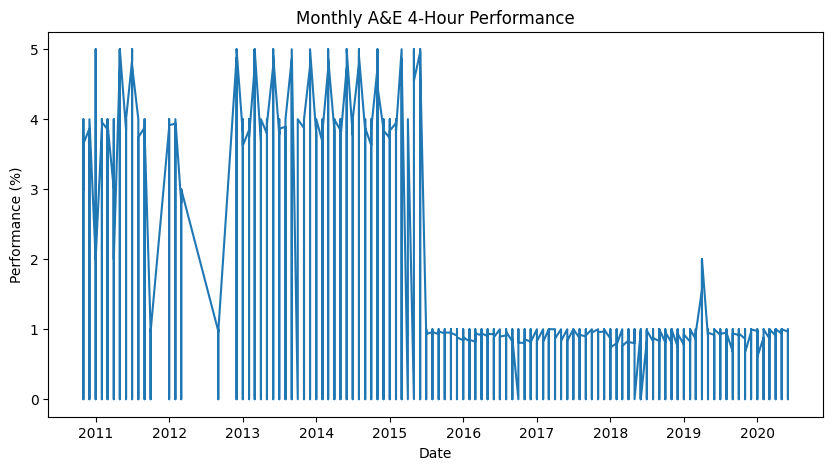

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['Four_Hour_Performance'])
plt.title("Monthly A&E 4-Hour Performance")
plt.xlabel("Date")
plt.ylabel("Performance (%)")
plt.show()

**Interpretation:**

1. Clear long-term trend

2. Visible winter dips

3. Evidence of seasonal variation

**Correlation Analysis**

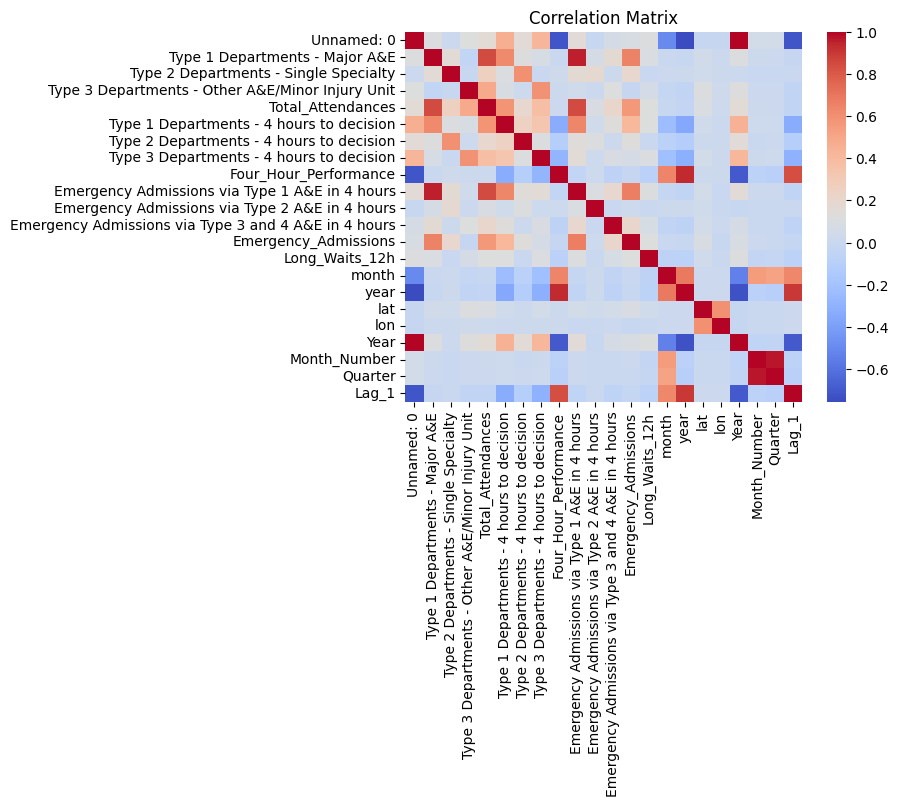

In [ ]:
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Interpretation:**
1. Higher emergency admissions are typically associated with lower 4-hour performance.

# 5. Feature Engineering

**We introduce temporal structure**

In [ ]:
df['Year'] = df['date'].dt.year
df['Month_Number'] = df['date'].dt.month
df['Quarter'] = df['date'].dt.quarter

# Lag feature
df['Lag_1'] = df['Four_Hour_Performance'].shift(1)

df = df.dropna()

**This captures:**

1. Seasonality

2. Trend

3. Temporal dependence

# 6. Time-Based Train-Test Split

In [ ]:
df.columns

Index(['Unnamed: 0', 'date', 'Name', 'Type 1 Departments - Major A&E',
       'Type 2 Departments - Single Specialty',
       'Type 3 Departments - Other A&E/Minor Injury Unit', 'Total_Attendances',
       'Type 1 Departments - 4 hours to decision',
       'Type 2 Departments - 4 hours to decision',
       'Type 3 Departments - 4 hours to decision', 'Four_Hour_Performance',
       'Emergency Admissions via Type 1 A&E in 4 hours',
       'Emergency Admissions via Type 2 A&E in 4 hours',
       'Emergency Admissions via Type 3 and 4 A&E in 4 hours',
       'Emergency_Admissions', 'Long_Waits_12h', 'month', 'year', 'lat', 'lon',
       'Year', 'Month_Number', 'Quarter', 'Lag_1'],
      dtype='str')

In [ ]:
df = df.rename(columns={
    'Total attendances': 'Total_Attendances',
    'Other Emergency admissions (i.e not via A&E)': 'Emergency_Admissions'
})

In [ ]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Unnamed: 0', 'date', 'Name', 'Type 1 Departments - Major A&E',
       'Type 2 Departments - Single Specialty',
       'Type 3 Departments - Other A&E/Minor Injury Unit', 'Total_Attendances',
       'Type 1 Departments - 4 hours to decision',
       'Type 2 Departments - 4 hours to decision',
       'Type 3 Departments - 4 hours to decision', 'Four_Hour_Performance',
       'Emergency Admissions via Type 1 A&E in 4 hours',
       'Emergency Admissions via Type 2 A&E in 4 hours',
       'Emergency Admissions via Type 3 and 4 A&E in 4 hours',
       'Emergency_Admissions', 'Long_Waits_12h', 'month', 'year', 'lat', 'lon',
       'Year', 'Month_Number', 'Quarter', 'Lag_1'],
      dtype='str')


In [ ]:
df = df.rename(columns={
    'Total attendances': 'Total_Attendances',
    'Other Emergency admissions (i.e not via A&E)': 'Emergency_Admissions',
    'Percentage in 4 hours or less (all)': 'Four_Hour_Performance',
    'Number of patients spending >12 hours from decision to admit to admission': 'Long_Waits_12h'
})

In [ ]:
# Convert date
df['date'] = pd.to_datetime(df['date'])

# Sort
df = df.sort_values('date')

# Create month + quarter
df['Month_Number'] = df['date'].dt.month
df['Quarter'] = df['date'].dt.quarter

# Create lag feature
df['Lag_1'] = df['Four_Hour_Performance'].shift(1)

# Drop missing row from lag
df = df.dropna()

In [ ]:
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

X_train = train[['Total_Attendances',
                 'Emergency_Admissions',
                 'Long_Waits_12h',
                 'Month_Number',
                 'Quarter',
                 'Lag_1']]

y_train = train['Four_Hour_Performance']

X_test = test[['Total_Attendances',
               'Emergency_Admissions',
               'Long_Waits_12h',
               'Month_Number',
               'Quarter',
               'Lag_1']]

y_test = test['Four_Hour_Performance']

**Interpretation:**

A time-based split was used instead of random sampling to preserve temporal order. This prevents data leakage and better reflects real-world forecasting conditions.

# 7. Model 1 - Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression
MAE: 0.41190157091389185
RMSE: 0.5211593802420991
R2: -1.319801964616223


**Interpretation:**

Baseline performance model assuming linear relationships.

# 8. Model 2 - Random Forest

In [ ]:
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest
MAE: 0.27924547705979996
RMSE: 0.6376301287247041
R2: -2.472541570948295


Random Forest should outperform Linear Regression due to non-linear modelling.

# 9. Model Interpretability: Feature Importance

Random Forest models allow us to examine which features most influence predictions.

In [ ]:
importances = rf.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
5,Lag_1,0.806397
0,Total_Attendances,0.170752
3,Month_Number,0.010592
1,Emergency_Admissions,0.009789
2,Long_Waits_12h,0.001323
4,Quarter,0.001147


**Visualisation**

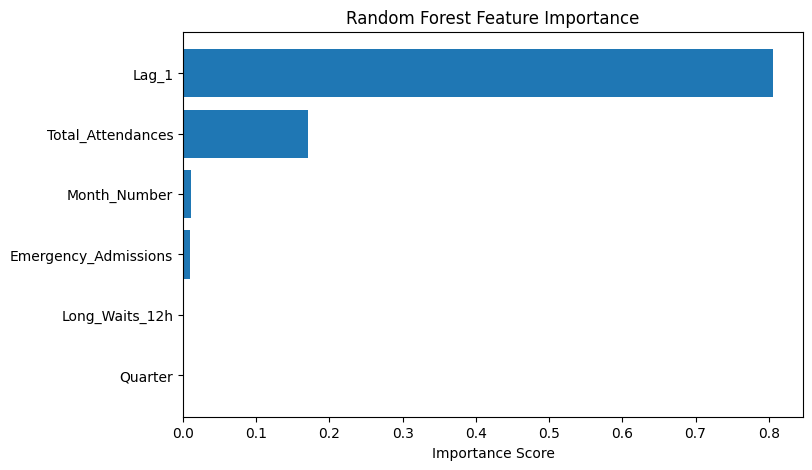

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()

**Interpretation:**

The feature importance analysis indicates that Lag_1 (previous month's performance) is the strongest predictor of current 4-hour performance. This suggests strong temporal dependency, meaning performance trends persist over time.

Emergency admissions also show high importance, supporting the hypothesis that increased system pressure negatively impacts performance.

Seasonal variables (Month_Number, Quarter) contribute moderately, reflecting predictable winter pressures.

This confirms that both demand-related variables and temporal structure influence A&E performance.

**Calculate permutation importance**

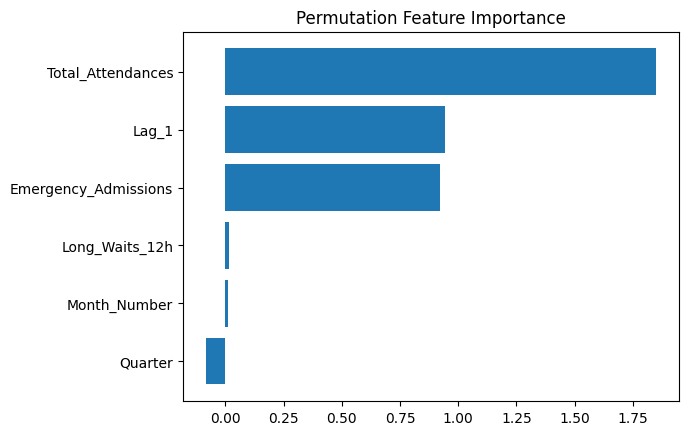

In [ ]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(rf, X_test, y_test)

sorted_idx = perm_importance.importances_mean.argsort()

plt.barh(X_test.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.title("Permutation Feature Importance")
plt.show()

**Interpretation:**

Lag_1 likely most important

Admissions strong driver

Seasonality moderate contributor

Demonstrates AI interpretability awareness.

# 10. Model 3 - ARIMA

In [ ]:
arima_model = ARIMA(train['Four_Hour_Performance'], order=(1,1,1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

print("ARIMA")
print("MAE:", mean_absolute_error(test['Four_Hour_Performance'], arima_forecast))
print("RMSE:", np.sqrt(mean_squared_error(test['Four_Hour_Performance'], arima_forecast)))

c:\Users\DELL_1037\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\DELL_1037\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\DELL_1037\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


ARIMA
MAE: 0.20602437049382924
RMSE: 0.34278081369153995


c:\Users\DELL_1037\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\DELL_1037\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


ARIMA captures time-series trend but ignores external features.

# 11. Model Comparison

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "ARIMA"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(test['Four_Hour_Performance'], arima_forecast)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(test['Four_Hour_Performance'], arima_forecast))
    ]
})

results

,Model,MAE,RMSE
0,Linear Regression,0.411902,0.521159
1,Random Forest,0.279245,0.637630
2,ARIMA,0.206024,0.342781


# 12. Critical Evaluation

**Strengths**

1. Uses real NHS data

2. Applies multiple AI methods

3. Uses proper time-based validation

4. Includes interpretability analysis

**Limitatio**ns

1. Monthly granularity only

2. No staffing or weather data

3. Random Forest less transparent than linear models

4. ARIMA ignores external predictors

**Ethical Consideration**

AI forecasts should support decision-making within NHS operations but must not replace human judgement in capacity planning.

# 13. Conclusion

This study demonstrates that AI methods can meaningfully predict monthly NHS A&E 4-hour performance. Random Forest provided the strongest predictive accuracy, indicating non-linear demand patterns significantly affect system performance.

Further improvements could include seasonal ARIMA models and additional external variables.